### PyTorch Workflow. ###

* Resources:
  1. https://www.learnpytorch.io/01_pytorch_workflow/
  2. https://docs.pytorch.org/docs/2.14/nn.html
* Content Cover:
  1. Data (Prepare and Load)
  2. Build Model
  3. Making Predictions and Evaluating a Model (Inference).
  4. Saving and loading a Model
  5. Putting it all toghethers

In [1]:
import torch
from torch import nn #-- nn means neural network. --#
import matplotlib.pyplot as plt
#-- Check PyTorch version. --#
print(f"Pytorch Version: {torch.__version__}")


Pytorch Version: 2.11.0+cpu


## 1. Data (Preparing and Loading). ##
  * Data has several different types including Excel Spreadsheet, Images, Videos, Audio, DNA, Text, and so on.
  * Machine Learning has two parts:
    + Get data into numerical representation.
    + Build a model to learn patterns in that numerical representation.
  * In this section, I'll use linear regression model with known **parameters**.

In [2]:
#-- Generate known parameters. --#
weight = 0.7
bias = 0.3
#-- Create. --#
start = 0
end = 1
step = 0.02
X = torch.arange(start=start, end=end, step=step).unsqueeze(dim=1)
y = weight*X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [3]:
len(X), len(y)

(50, 50)

## 2. Split into Training and Testing Sets. ##

In [4]:
#-- Generate Train Test Split. --#
train_split = int (0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
print(f"Len of X_train: {len(X_train)}")
print(f"Len of y_train: {len(y_train)}")
print(f"Len of X_test: {len(X_test)}")
print(f"Len of y_test: {len(y_test)}")

Len of X_train: 40
Len of y_train: 40
Len of X_test: 10
Len of y_test: 10


### 2.1 Visualize ###

In [5]:
def plot_predictions(train_data=X_train,
                      train_labels=y_train,
                      test_data=X_test,
                      test_labels=y_test,
                      predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10,7))
  #-- Plot training data in blue. --#
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training Data")
  #-- Plot test data in green. --#
  plt.scatter(test_data, test_labels, c="g", s=4, label='Test Data')
  #-- Are there Predictions. --#
  if predictions is not None:
    plt.scatter(test_data, predictions, c="r", s=4, label='Prediction')
  #-- Show. --#
  plt.legend(prop={'size':14})

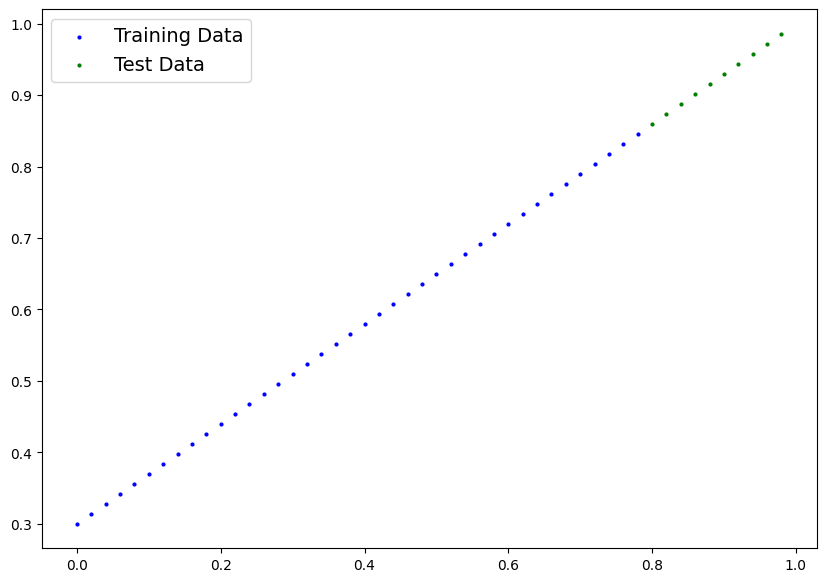

In [ ]:
plot_predictions()

## 3. Build first model. ##

In [6]:
from torch import nn

class LinearRegressionModel(nn.Module): #<-- Almost everything in Pytorch inherit from nn.Module. --#
  def __init__(self):
    super().__init__()
    #-- Initialize Model Parameters. --#
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True,
                                            dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
  #-- Forward method to define the computation in the model. --#
  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.weights * x + self.bias

### 3.1 PyTorch Essential Neural Network building Modules. ###

  1. torch.nn -> Contains all of the building blocks for computational graphs (essentially a series of computations executed in a particular way).
  2. torch.nn.Module -> The base class for all neuron network modules, all the building blocks for neural networks are subclasses. If building a neural network in Pytorch, model should have subclass **nn.Module** which requires a **forward()** method can be implemented.
  3. torch.optim -> Contains various optimization algorithms (these tell the model parameters stored in **nn.Parameter** how to best change to improve gradient descent an in tur reduce the loss).
  4. torch.utils.data.Dataset -> Represents a map between key(label) and sample(features) pairs of data such as images and associated labels.
  5. torch.utils.dataset.DataLoader -> Creates a Python iterable over a torch Dataset (allows to iterate over data).
  6. Link: https://docs.pytorch.org/tutorials/index.html

In [7]:
torch.manual_seed(42)
torch.randn(1)

tensor([0.3367])

### 3.2 Checking the content of PyTorch Model. ###

In [8]:
#-- Generate a random seed. --#
#-- torch.manual_seed(42). --#
#-- Generate an instance of the model. --#
model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [9]:
#-- List name parameters. --#
model_0.state_dict()

OrderedDict([('weights', tensor([0.1288])), ('bias', tensor([0.2345]))])

## 4. Making Prediction using torch.inference_mode(). ##

In [10]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3375],
        [0.3401],
        [0.3427],
        [0.3452],
        [0.3478],
        [0.3504],
        [0.3530],
        [0.3555],
        [0.3581],
        [0.3607]], grad_fn=<AddBackward0>)

In [11]:
X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [12]:
#-- Make prediction. --#
with torch.inference_mode():
  y_preds = model_0(X_test)
with torch.no_grad():
  y_preds = model_0(X_test)
y_preds

tensor([[0.3375],
        [0.3401],
        [0.3427],
        [0.3452],
        [0.3478],
        [0.3504],
        [0.3530],
        [0.3555],
        [0.3581],
        [0.3607]])

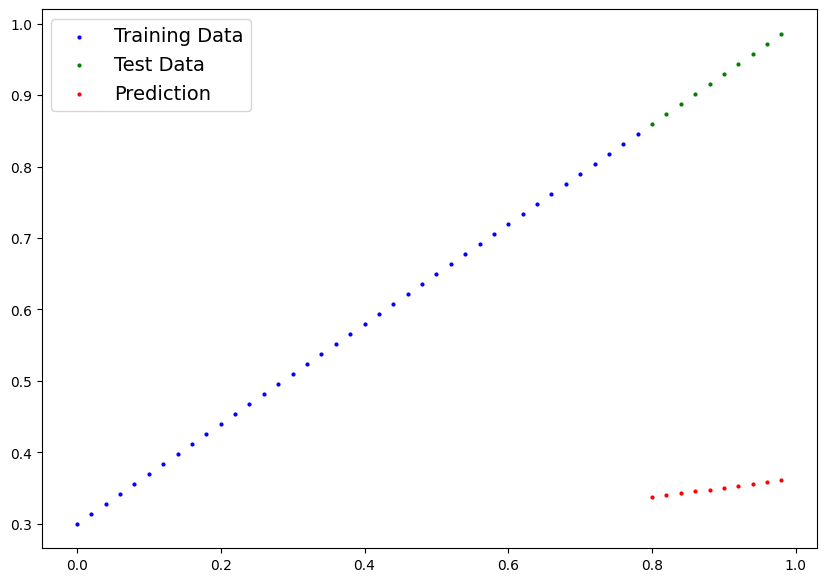

In [13]:
plot_predictions(predictions=y_preds)

## 5. Train the Model. ##

In [14]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [15]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.1288])), ('bias', tensor([0.2345]))])

In [16]:
#-- Setup a loss function. --#
loss_fn = nn.L1Loss()
#-- Setup an optimizer. --#
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.00001)

## 6. Training a Loop. ##

In [17]:
with torch.no_grad():
  model_0.parameters()

In [18]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.1288], requires_grad=True),
 Parameter containing:
 tensor([0.2345], requires_grad=True)]

In [31]:
epochs = 100
for epoch in range(epochs):
  model_0.train()
  #-- Forward Pass. --#
  y_preds = model_0(X_train)
  #-- Calculate the loss. --#
  loss = loss_fn(y_preds, y_train)
  #-- Optimizer Zero Grad. --#
  optimizer.zero_grad()
  #-- Perform backpropagation. --#
  loss.backward()
  #-- Step the optimizer. --#
  optimizer.step()
  model_0.eval()
  with torch.inference_mode():
    test_preds = model_0(X_test)
    test_loss = loss_fn(test_preds, y_test)
  print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
  print(model_0.state_dict())

Epoch: 0 | Loss: 0.28823283314704895 | Test Loss: 0.5738030076026917
OrderedDict({'weights': tensor([0.1288]), 'bias': tensor([0.2345])})
Epoch: 1 | Loss: 0.2882212996482849 | Test Loss: 0.5737894773483276
OrderedDict({'weights': tensor([0.1288]), 'bias': tensor([0.2345])})
Epoch: 2 | Loss: 0.28820982575416565 | Test Loss: 0.5737760663032532
OrderedDict({'weights': tensor([0.1288]), 'bias': tensor([0.2346])})
Epoch: 3 | Loss: 0.2881982922554016 | Test Loss: 0.5737625360488892
OrderedDict({'weights': tensor([0.1288]), 'bias': tensor([0.2346])})
Epoch: 4 | Loss: 0.2881867289543152 | Test Loss: 0.5737490653991699
OrderedDict({'weights': tensor([0.1289]), 'bias': tensor([0.2346])})
Epoch: 5 | Loss: 0.28817522525787354 | Test Loss: 0.5737355947494507
OrderedDict({'weights': tensor([0.1289]), 'bias': tensor([0.2346])})
Epoch: 6 | Loss: 0.2881637215614319 | Test Loss: 0.5737221240997314
OrderedDict({'weights': tensor([0.1289]), 'bias': tensor([0.2346])})
Epoch: 7 | Loss: 0.28815215826034546 |

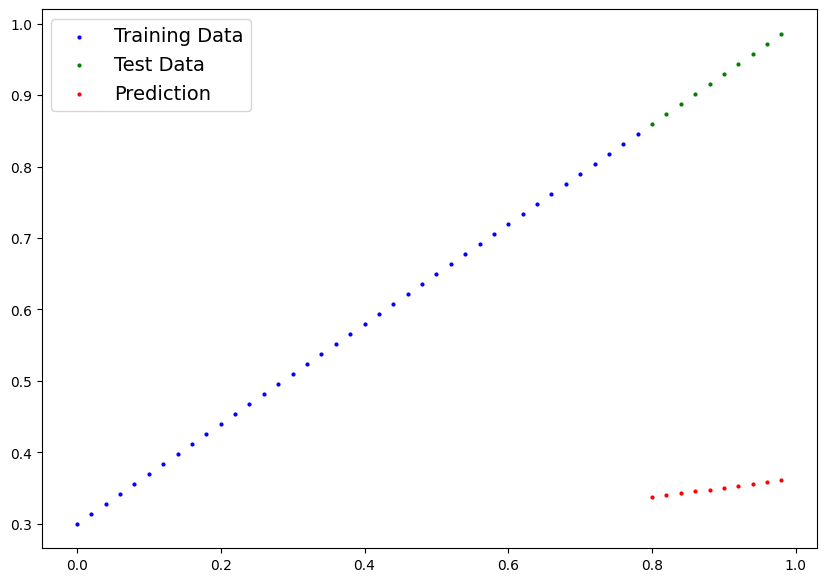

In [29]:
with torch.inference_mode():
  y_preds_new = model_0(X_test)
plot_predictions(predictions=y_preds_new)

In [23]:
weight, bias

(0.7, 0.3)

## 7.Saving a Model in PyTorch. ##

In [33]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = 'Pytorch_Workflow.pth'
MODEL_SAVE_PATH= MODEL_PATH / MODEL_NAME
print(f"Saving Model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)


Saving Model to: models/Pytorch_Workflow.pth


In [34]:
!ls -l models

total 4
-rw-r--r-- 1 root root 1965 Sep  4 06:54 Pytorch_Workflow.pth


In [35]:
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [39]:
loaded_model_0.eval()
with torch.inference_mode():
  y_preds = model_0(X_test)
y_preds

tensor([[0.3389],
        [0.3415],
        [0.3441],
        [0.3467],
        [0.3492],
        [0.3518],
        [0.3544],
        [0.3570],
        [0.3596],
        [0.3622]])

In [40]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

## 8. Putting it Toghether. ##

### 8.1 Data. ###

In [41]:
import torch
from torch import nn
import matplotlib.pyplot as plt
print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.11.0+cpu


In [43]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device use: {device}")

Device use: cpu


In [47]:
#-- Create some data using linear regression. --#
weight = 0.7
bias = 0.3
#-- Create range value. --#
start = 0
end = 1
step = 0.02
#-- Create X and y. --#
X = torch.arange(start=start, end=end, step=step).unsqueeze(dim=1)
y = weight * X + bias
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [48]:
#-- Split the Data. --#
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

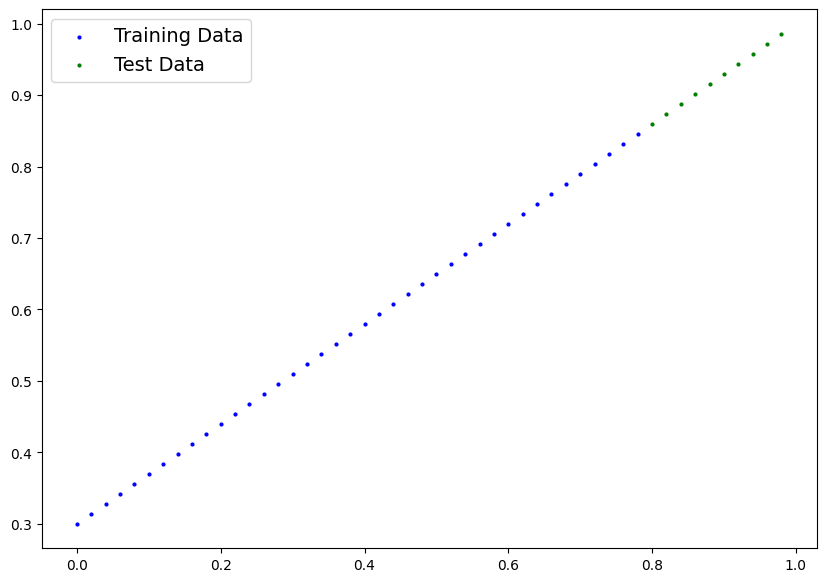

In [49]:
plot_predictions(X_train, y_train, X_test, y_test)

### 8.2 Building a PyTorch Linear Model. ###

In [55]:
#-- Generate Linear Model by subclassing nn.Module. --#
class LinearRegressionModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    #-- Using nn.Linear() for creating Parameters. --#
    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1)

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [57]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [56]:
X_train[:5], y_train[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560]]))

### 8.3 Training. ###

In [58]:
#-- Setup Loss Function. --#
loff_fn = nn.L1Loss()
#-- Setup optimizer. --#
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.01)
#-- Create a training loop. --#
torch.manual_seed(42)
epochs = 200
for epoch in range(epochs):
  model_1.train()
  #-- Forward pass. --#
  y_pred = model_1(X_train)
  #-- Calculate the loss. --#
  loss = loff_fn(y_pred, y_train)
  #-- Optimizer zero grad. --#
  optimizer.zero_grad()
  #- Perfrom backpropagation. --#
  loss.backward()
  #-- Optimizer Step. --#
  optimizer.step()
  model_1.eval()
  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loff_fn(test_pred, y_test)
  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 0.5551779866218567 | Test Loss: 0.5739762187004089
Epoch: 10 | Loss: 0.4399680495262146 | Test Loss: 0.4392663538455963
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss: 0.30455657839775085
Epoch: 30 | Loss: 0.20954827964305878 | Test Loss: 0.16984674334526062
Epoch: 40 | Loss: 0.09433844685554504 | Test Loss: 0.03513689711689949
Epoch: 50 | Loss: 0.023886386305093765 | Test Loss: 0.04784906655550003
Epoch: 60 | Loss: 0.0199567973613739 | Test Loss: 0.04580312222242355
Epoch: 70 | Loss: 0.016517987474799156 | Test Loss: 0.0375305712223053
Epoch: 80 | Loss: 0.013089170679450035 | Test Loss: 0.029944902285933495
Epoch: 90 | Loss: 0.009653178043663502 | Test Loss: 0.02167237363755703
Epoch: 100 | Loss: 0.006215679459273815 | Test Loss: 0.014086711220443249
Epoch: 110 | Loss: 0.002787243574857712 | Test Loss: 0.005814164876937866
Epoch: 120 | Loss: 0.0012645035749301314 | Test Loss: 0.013801807537674904
Epoch: 130 | Loss: 0.0012645035749301314 | Test Loss: 0.01380180753767

In [59]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [60]:
weight, bias

(0.7, 0.3)

### 8.4 Making and Evaluating prediction. ###

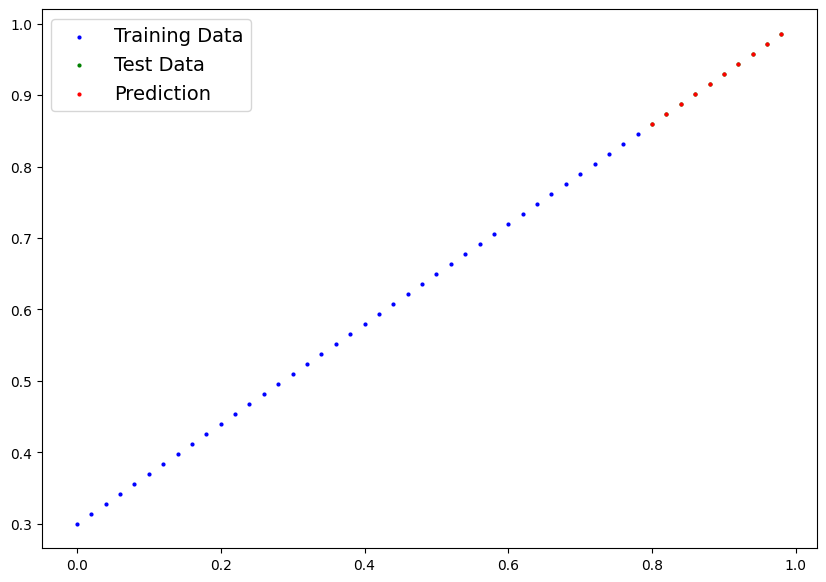

In [61]:
model_1.eval()
with torch.inference_mode():
  y_preds = model_1(X_test)
plot_predictions(predictions=y_preds)

In [62]:
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]])

### 8.5 Saving and Loading Model. ###

In [64]:
from pathlib import Path
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "Pytorch_Workflow_V2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
torch.save(obj=model_1.state_dict(),
           f=MODEL_SAVE_PATH)

In [65]:
loaded_model_2 = LinearRegressionModelV2()
loaded_model_2.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>